  <h1 style="margin: 0;"><strong>Data Mining Project: Amazing International Airlines Inc.</strong></h1>
  <h2 style="margin: 0;"><strong>Part 2/2: Clustering</strong></h2>
</div>

<div style="text-align: left; margin-top: 15px;">
  <p style="margin: 0;"><strong>Group 51:</strong></p>
  <ul style="margin: 0; padding-left: 20px;">
    <li>André Ferreira | 20250398</li>
    <li>Fausto Gomes | 20221915</li>
    <li>Maria Francisca Gonçalves | 20221942</li>
    <li>Miguel Matos | 20221925</li>
  </ul>
</div>


## <h2 style="color: #ffffffff; background-color: #1d4e81; text-align: center; padding: 6px; font-family: 'Arial';">0. Context</h2>

ADICIONAR TEXTO !!!!!!!!!!!

## <h2 style="color: #ffffffff; background-color: #1d4e81; text-align: center; padding: 6px; font-family: 'Arial';">1. Libraries & Data Importation</h2>

In [2]:
import os
import sys
import warnings

import sys
sys.path.append('../')

# Suppress warnings
warnings.filterwarnings('ignore')

### Basic Libraries
import numpy as np
import pandas as pd

### Sklearn
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

NOTA: PASSAR ISTO TUDO PARA .PY !!!

In [3]:
#FUNÇOES

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
from PIL import Image
import urllib
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import silhouette_score, confusion_matrix
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import umap
import math

def set_plot_properties(ax, x_label, y_label, y_lim=[]):
    """
    Set properties of a plot axis.

    Args:
        ax (matplotlib.axes.Axes): The axis object of the plot.
        x_label (str): The label for the x-axis.
        y_label (str): The label for the y-axis.
        y_lim (list, optional): The limits for the y-axis. Defaults to [].

    Returns:
        None
    """
    ax.set_xlabel(x_label)  # Set the label for the x-axis
    ax.set_ylabel(y_label)  # Set the label for the y-axis
    if len(y_lim) != 0:
        ax.set_ylim(y_lim)  # Set the limits for the y-axis if provided


def plot_inertia_and_silhouette(data, k_min=2, k_max=15):
    """
    Plot the inertia (dispersion) and silhouette score for different numbers of clusters.

    Args:
        data (numpy.ndarray or pandas.DataFrame): The input data for clustering.
        k_min (int, optional): The minimum number of clusters to evaluate. Defaults to 2.
        k_max (int, optional): The maximum number of clusters to evaluate. Defaults to 15.

    Returns:
        None
    """
    dispersions = []
    scores = []

    k_clusters = range(k_min, k_max + 1)

    for k in k_clusters:
        kmeans = KMeans(n_clusters=k, random_state=0).fit(data)
        dispersions.append(kmeans.inertia_)  # Calculate the dispersion (inertia) for each number of clusters
        kmeans.predict(data)
        scores.append(silhouette_score(data, kmeans.labels_, metric='euclidean'))  # Calculate the silhouette score

    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.plot(k_clusters, dispersions, marker='o')  # Plot the inertia (dispersion)
    set_plot_properties(ax1, 'Number of clusters', 'Dispersion (inertia)')
    ax2.plot(k_clusters, scores, marker='o')  # Plot the silhouette score
    set_plot_properties(ax2, 'Number of clusters', 'Silhouette score')

    plt.show()


def plot_dendrogram(data, linkage_method, cut_line=None):
    """
    Plot a dendrogram for hierarchical clustering.

    Args:
        data (numpy.ndarray or pandas.DataFrame): The input data for clustering.
        linkage_method (str): The linkage method used for clustering.
        cut_line (float, optional): The threshold value to cut the dendrogram. Defaults to None.

    Returns:
        None
    """
    # Fit the AgglomerativeClustering model
    model = AgglomerativeClustering(linkage=linkage_method, distance_threshold=0, n_clusters=None).fit(data)

    # Create the plot
    fig, ax = plt.subplots()
    plt.title('Hierarchical Clustering Dendrogram')

    # Create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # Leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    # Create the linkage matrix
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)

    # Plot the dendrogram
    dendrogram(linkage_matrix, truncate_mode='level', p=50)

    # Add a cut line if provided
    if cut_line is not None:
        plt.axhline(y=cut_line, color='black', linestyle='-')

    # Display the plot
    plt.show()


def plot_umap_projections(people, cluster_columns, n_components=2, random_state=42):
    """
    Generates UMAP projections for multiple clustering methods and plots them in a grid.

    Parameters:
    people (DataFrame): The input data containing the features and cluster assignments.
    cluster_columns (list of str): The list of column names containing cluster assignments for each method.
    n_components (int): Number of dimensions for UMAP projection. Default is 2.
    random_state (int): Random state for UMAP. Default is 42.
    """
    # Check if at least one cluster column is provided
    if len(cluster_columns) < 1:
        raise ValueError("At least one cluster column must be provided.")

    # Determine the layout of subplots
    num_plots = len(cluster_columns)
    num_rows = math.ceil(math.sqrt(num_plots))
    num_cols = math.ceil(num_plots / num_rows)

    # Create the subplots
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(16, 12))
    axs = axs.flatten()  # Flatten the array of axes

    for i, cluster_column in enumerate(cluster_columns):
        # Check if the necessary columns are present in the dataframe
        if cluster_column not in people.columns:
            raise ValueError(f"Cluster column '{cluster_column}' not found in the data.")

        # Separate features and clusters
        features = people.drop(columns=[cluster_column])
        clusters = people[cluster_column]

        # Perform UMAP
        reducer = umap.UMAP(n_components=n_components, random_state=random_state)
        umap_embedding = reducer.fit_transform(features)

        # Plot the UMAP embedding
        scatter = axs[i].scatter(
            umap_embedding[:, 0], umap_embedding[:, 1],
            c=clusters, cmap='Spectral', s=5
        )
        axs[i].set_title(f'UMAP projection of {cluster_column}')
        axs[i].set_xlabel('UMAP 1')
        axs[i].set_ylabel('UMAP 2')

        # Add a color bar to each subplot
        cbar = plt.colorbar(scatter, ax=axs[i], boundaries=np.arange(clusters.nunique() + 1) - 0.5)
        cbar.set_ticks(np.arange(clusters.nunique()))

    # Remove any unused subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    # Adjust layout
    plt.tight_layout()
    plt.show()


def groupby_mean(data, variable, n_features=30):
    """
    Group the data by a variable and calculate the mean for each group.

    Args:
        data (pandas.DataFrame): The input data.
        variable (str): The variable used for grouping.
        n_features (int, optional): The number of features to include in the result. Defaults to 30.

    Returns:
        pandas.DataFrame: The transposed DataFrame containing the mean values for each group.
    """
    # Group the data by the specified variable and calculate the mean for each group
    grouped_data = data.groupby(variable).mean()

    # SelectA the first n_features + 1 columns (including the variable column) and transpose the DataFrame
    result = grouped_data.iloc[:, :n_features + 1].T

    # Return the transposed DataFrame
    return result

In [4]:
def correlation_matrix(data, threshold, x, y):

    """
    correlation_matrix plots a Pearson correlation matrix heatmap for numerical features in a dataset,
    displaying correlation values only when their absolute value exceeds a given
    threshold. We used it to analyse the correlation between our numerical features in EDA.

    Parameters:
    data : Input dataset containing numerical variables.
    
    threshold : Minimum absolute correlation value required for a cell to be annotated

    Returns: None, displays a correlation heatmap.
    """
    
    corr = data.corr(method="pearson")
    corr = corr.round(2)

    mask_annot = np.absolute(corr.values) >= threshold

    annot = np.where(mask_annot, corr.values, np.full(corr.shape,"")) 

    fig = plt.figure(figsize=(x, y))

    # Plotting the heatmap of the correlation matrix
    sns.heatmap(data=corr, 
                annot=annot, # Specifing custom annotation
                fmt='s', # The annotation matrix now has strings, so we need to explicitly say this
                vmin=-1, vmax=1, 
                center=0,
                square=True, # Make each cell square-shaped
                linewidths=.5, # Adding lines between cells
                cmap='PiYG' # Diverging color map
                )

    plt.show()


In [5]:
data = pd.read_csv("../data/cleaned_data/clustering_data_cleaned.csv", index_col = 'Loyalty#')

## <h2 style="color: #ffffffff; background-color: #1d4e81; text-align: center; padding: 6px; font-family: 'Arial';">2. Data Segmentation and Selection</h2>

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16715 entries, 100011 to 999999
Data columns (total 63 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Income                          16715 non-null  float64
 1   Customer Lifetime Value         16715 non-null  float64
 2   EnrollmentType                  16715 non-null  int64  
 3   rejoined_program                16715 non-null  int64  
 4   Days_in_prog                    16715 non-null  float64
 5   Cancelled_program               16715 non-null  int64  
 6   Enrollment_year                 16715 non-null  int64  
 7   Enrollment_month                16715 non-null  int64  
 8   TotalFlights                    16715 non-null  float64
 9   TotalDistance                   16715 non-null  float64
 10  TotalPointsAccumulated          16715 non-null  float64
 11  TotalPointsRedeemed             16715 non-null  float64
 12  Flights_per_day                

voltar a correr e verificar clusters

In [7]:
value_based_data = data[["Customer Lifetime Value", "Income", "TotalPointsAccumulated", 
                              "TotalPointsRedeemed"]].copy()

## Correlation Matrix

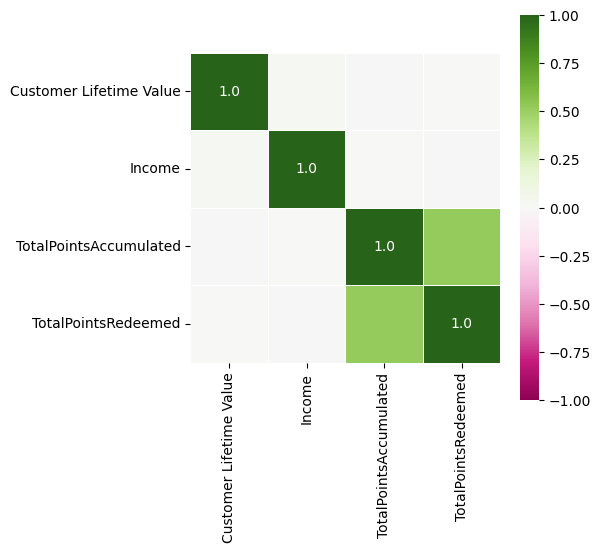

In [8]:
correlation_matrix(value_based_data, 0.7, 5, 5)

In [9]:
value_based_data.to_csv("../data/clustering_data/value_based_data.csv")

## <h1 style="color: #ffffffff; background-color: #1d4e81; text-align: center; padding: 4px; font-family: 'Arial';">Modelling</h1>

### Methodology Overview

**Scaling Approach:** We test three different scaling methods (StandardScaler, MinMaxScaler, RobustScaler) because customer value features vary significantly in range and distribution. We empirically determine which scaler best reveals natural customer value clusters in our specific dataset, rather than assuming one method will work optimally. <br>

**Hierarchical filtering approach**: progressively identifies and extract clear customer segments, through multiple examinations. <br>

This approach allows us to:
- Avoid forcing ambiguous customers into inappropriate segments; <br>
- Achieve higher precision for clear segments; <br>
- Better resolve transitional or mixed behavioral patterns in later iterations, <br>
- Understands the better scaling method in pratical terms. <br>

<!-- ## <h2 style="color: #1322f8ff; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Perspective 1: VALUE-BASED SEGMENTATION</h2> -->

## <h2 style="color: #333333; background-color: #d6fff4; text-align: center; padding:4px; font-family: 'Arial';">Filtering: Examination 1</h2>

In [10]:
value_based_data = value_based_data.copy()

In [11]:
for column in value_based_data.columns:
    if column.startswith('Total_Spend_Month_'):
        value_based_data[column] = np.sqrt(value_based_data[column])

In [12]:
#adicionei por um erro, rever funcções
st_scaler = StandardScaler().set_output(transform="pandas")
mm_scaler = MinMaxScaler().set_output(transform="pandas")
rb_scaler = RobustScaler().set_output(transform="pandas")

# necessário
value_st_scl = st_scaler.fit_transform(value_based_data)
value_mm_scl = mm_scaler.fit_transform(value_based_data)
value_rb_scl = rb_scaler.fit_transform(value_based_data)

## 1. Standard Scaling

### 1.1 K-Means

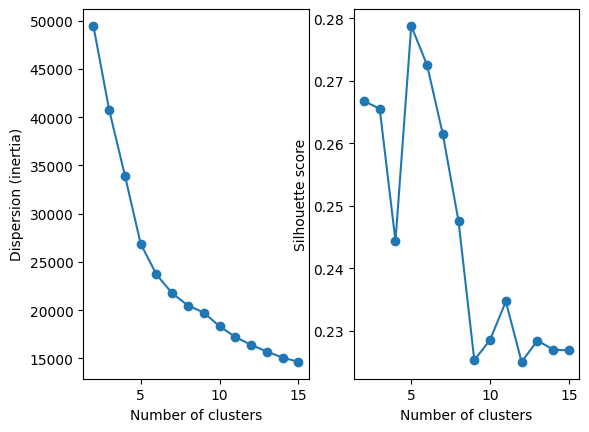

In [13]:
plot_inertia_and_silhouette(value_st_scl)

In [14]:
kmeans_st_scl = KMeans(n_clusters=5, random_state=42).fit(value_st_scl)
data['st_scaled_km_cluster5'] = kmeans_st_scl.predict(value_st_scl)

In [15]:
value_st_scl['st_scaled_km_cluster5'] = data['st_scaled_km_cluster5'] 
groupby_mean(value_st_scl, 'st_scaled_km_cluster5', n_features=4)  

st_scaled_km_cluster5,0,1,2,3,4
Customer Lifetime Value,-0.237990,-0.220770,-0.143710,-0.194882,2.918881
Income,-0.747496,-0.755845,0.969999,1.007572,-0.021417
TotalPointsAccumulated,0.660516,-0.977059,-1.181109,0.622754,0.096868
TotalPointsRedeemed,0.594670,-0.762458,-0.771273,0.324606,0.003347


### 1.2 Hierarchical - Ward

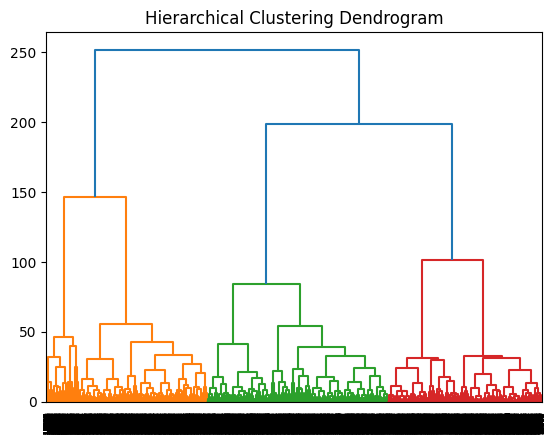

In [16]:
plot_dendrogram(value_st_scl, 'ward')

In [17]:
data['st_scaled_ward_cluster5'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 5
    ).fit_predict(value_st_scl)

In [18]:
value_st_scl['st_scaled_ward_cluster5'] = data['st_scaled_ward_cluster5']
groupby_mean(value_st_scl, 'st_scaled_ward_cluster5', n_features=4)

st_scaled_ward_cluster5,0,1,2,3,4
Customer Lifetime Value,-0.245842,-0.194882,-0.198750,2.918881,-0.143710
Income,-0.749280,1.007572,-0.754296,-0.021417,0.969999
TotalPointsAccumulated,0.583077,0.622754,-1.269167,0.096868,-1.181109
TotalPointsRedeemed,0.410089,0.324606,-0.741303,0.003347,-0.771273
st_scaled_km_cluster5,0.128879,3.000000,1.000000,4.000000,2.000000


## 2. MinMax Scaling

### 2.1 K-Means

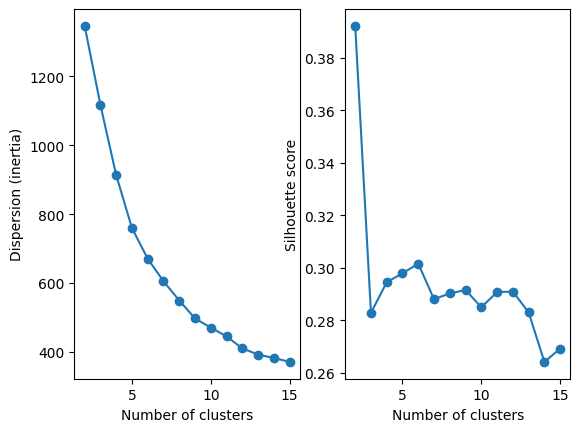

In [19]:
plot_inertia_and_silhouette(value_mm_scl)

In [20]:
#anteriormente fiz com 8, ficou boa mas senti q ainda podia estar melhor portanto testei 10 para filtrar mais numa 2ª examinação
kmeans_mm_scl = KMeans(n_clusters=5, random_state=42).fit(value_mm_scl)
data['mm_scaled_km_cluster5'] = kmeans_mm_scl.predict(value_mm_scl)

In [21]:
value_mm_scl['mm_scaled_km_cluster5'] = data['mm_scaled_km_cluster5']  
groupby_mean(value_mm_scl, 'mm_scaled_km_cluster5', n_features=4)

mm_scaled_km_cluster5,0,1,2,3,4
Customer Lifetime Value,0.070008,0.076927,0.075730,0.077098,0.072982
Income,0.020524,0.348675,0.761086,0.670155,0.151752
TotalPointsAccumulated,0.362273,0.362393,0.369142,0.091436,0.077197
TotalPointsRedeemed,0.219827,0.211457,0.222425,0.030957,0.026667


### 2.2 Hierarchical - Ward

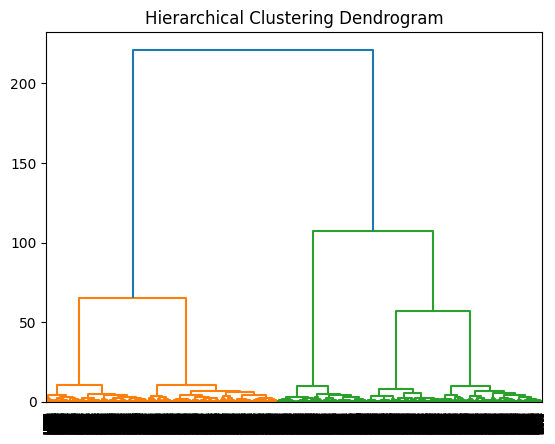

In [22]:
plot_dendrogram(value_mm_scl, 'ward')

In [23]:
data['mm_scaled_ward_cluster5'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 5
    ).fit_predict(value_mm_scl)

In [24]:
value_mm_scl['mm_scaled_ward_cluster5'] = data['mm_scaled_ward_cluster5']
groupby_mean(value_mm_scl, 'mm_scaled_ward_cluster5', n_features=4)

mm_scaled_ward_cluster5,0,1,2,3,4
Customer Lifetime Value,0.076927,0.070008,0.072982,0.075730,0.077098
Income,0.348675,0.020524,0.151752,0.761086,0.670155
TotalPointsAccumulated,0.362393,0.362273,0.077197,0.369142,0.091436
TotalPointsRedeemed,0.211457,0.219827,0.026667,0.222425,0.030957
mm_scaled_km_cluster5,1.000000,0.000000,4.000000,2.000000,3.000000


## 3. Robust Scaling

### 3.1 K-Means

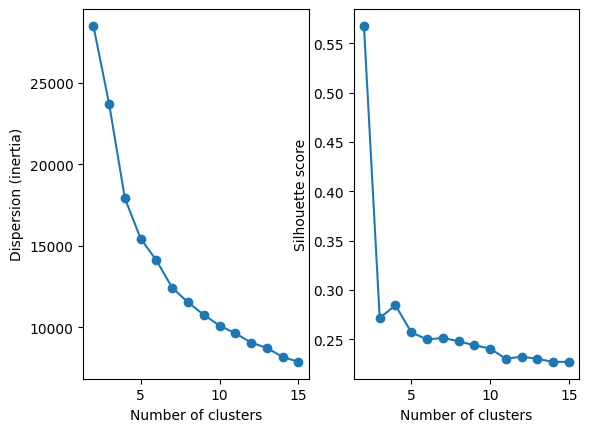

In [25]:
plot_inertia_and_silhouette(value_rb_scl)


In [26]:
kmeans_rb_scl = KMeans(n_clusters=5, random_state=42).fit(value_rb_scl)
data['rb_scaled_km_cluster5'] = kmeans_rb_scl.predict(value_rb_scl)

In [27]:
value_rb_scl['rb_scaled_km_cluster5'] = data['rb_scaled_km_cluster5']
groupby_mean(value_rb_scl, 'rb_scaled_km_cluster5', n_features=4)

rb_scaled_km_cluster5,0,1,2,3,4
Customer Lifetime Value,0.879292,-0.271736,-0.044102,6.640214,3.012393
Income,0.105609,0.035166,0.054852,0.107601,0.042477
TotalPointsAccumulated,0.126402,0.234802,-0.865291,-0.175856,-0.228848
TotalPointsRedeemed,0.234389,0.502271,-0.360724,0.152653,0.078994


### 3.2 Hierarchical - Ward

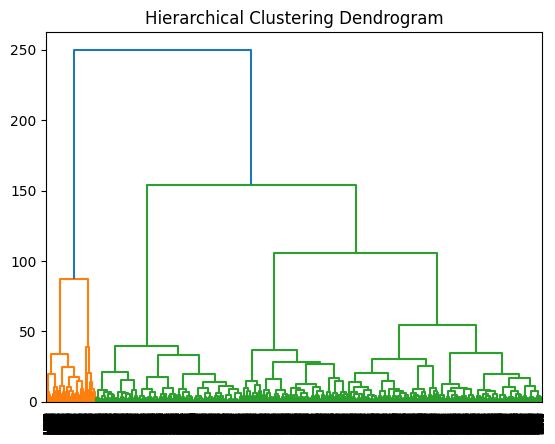

In [28]:
plot_dendrogram(value_rb_scl, 'ward')


In [29]:
data['rb_scaled_ward_cluster5'] = AgglomerativeClustering(
    linkage='ward', n_clusters=5
).fit_predict(value_rb_scl)

In [30]:
value_rb_scl['rb_scaled_ward_cluster5'] = data['rb_scaled_ward_cluster5']
groupby_mean(value_rb_scl, 'rb_scaled_ward_cluster5', n_features=4)

rb_scaled_ward_cluster5,0,1,2,3,4
Customer Lifetime Value,-0.271736,6.640214,-0.044102,0.879292,3.012393
Income,0.035166,0.107601,0.054852,0.105609,0.042477
TotalPointsAccumulated,0.234802,-0.175856,-0.865291,0.126402,-0.228848
TotalPointsRedeemed,0.502271,0.152653,-0.360724,0.234389,0.078994
rb_scaled_km_cluster5,1.000000,3.000000,2.000000,0.000000,4.000000


## 4. Cluster Visualization 1

In [31]:
clusters_km = ['st_scaled_km_cluster5', 'mm_scaled_km_cluster5', 'rb_scaled_km_cluster5']

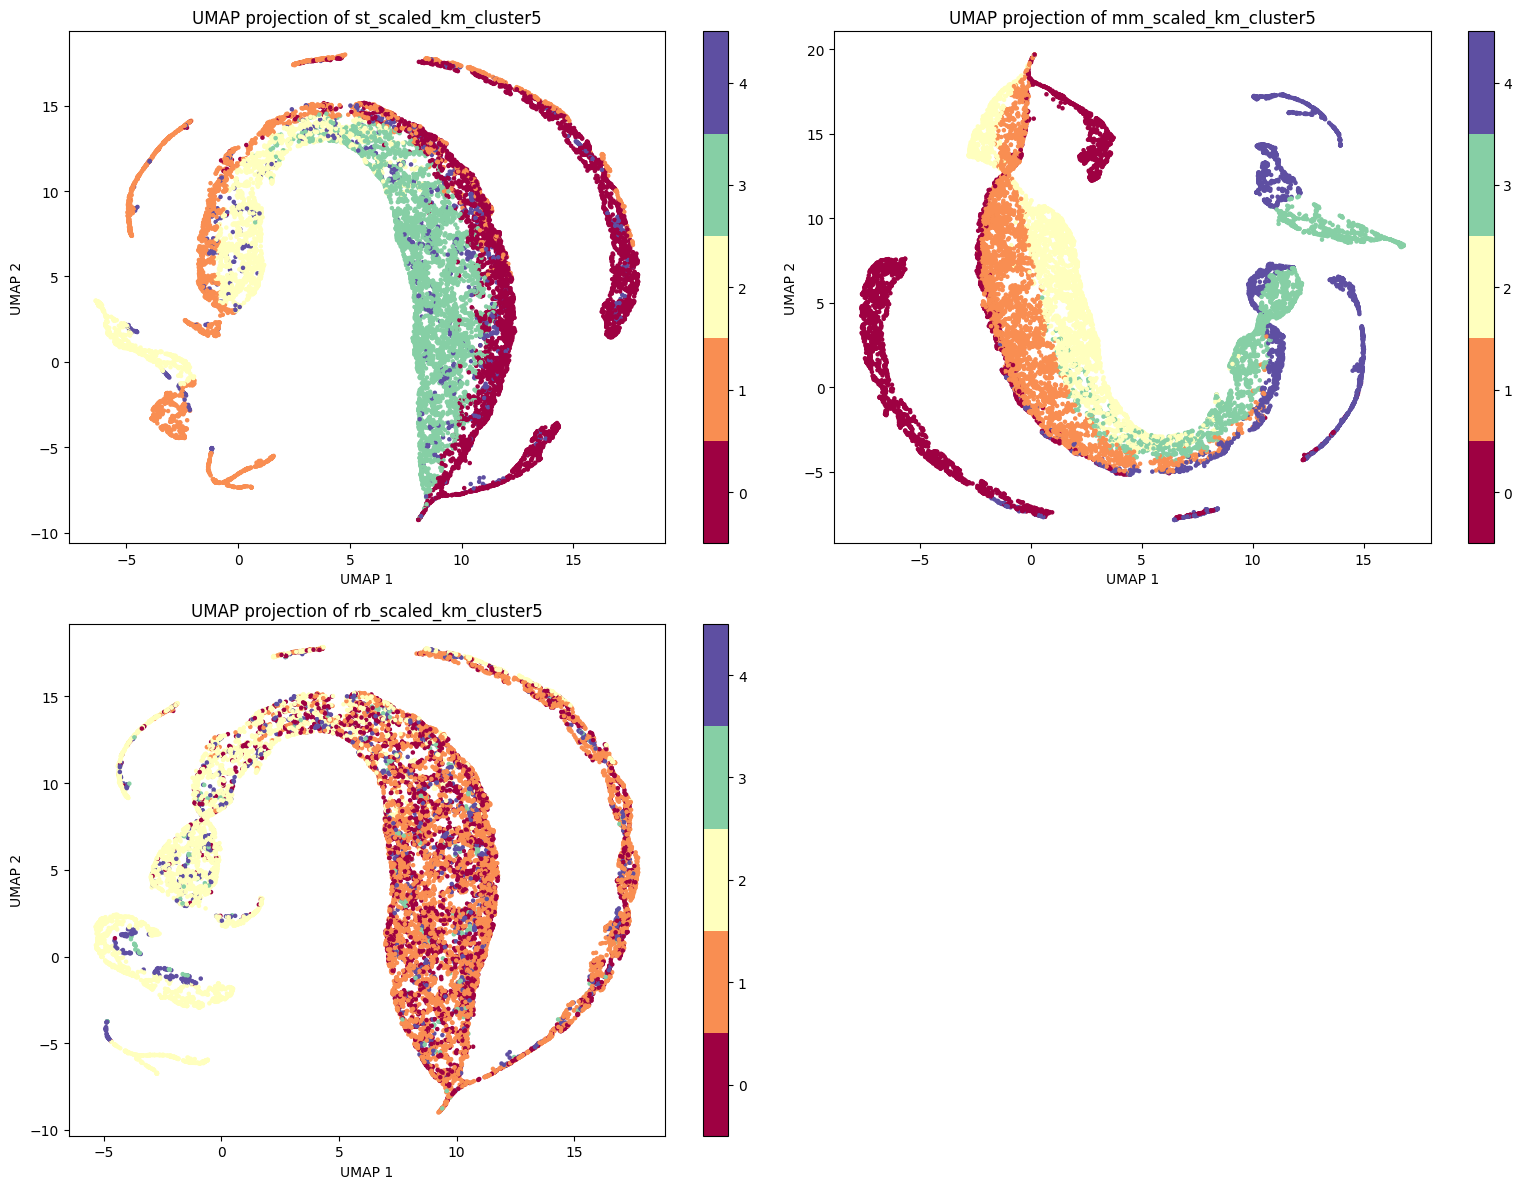

In [32]:
plot_umap_projections(data, clusters_km)

In [33]:
cluster_ward = ['st_scaled_ward_cluster5', 'mm_scaled_ward_cluster5', 'rb_scaled_ward_cluster5']

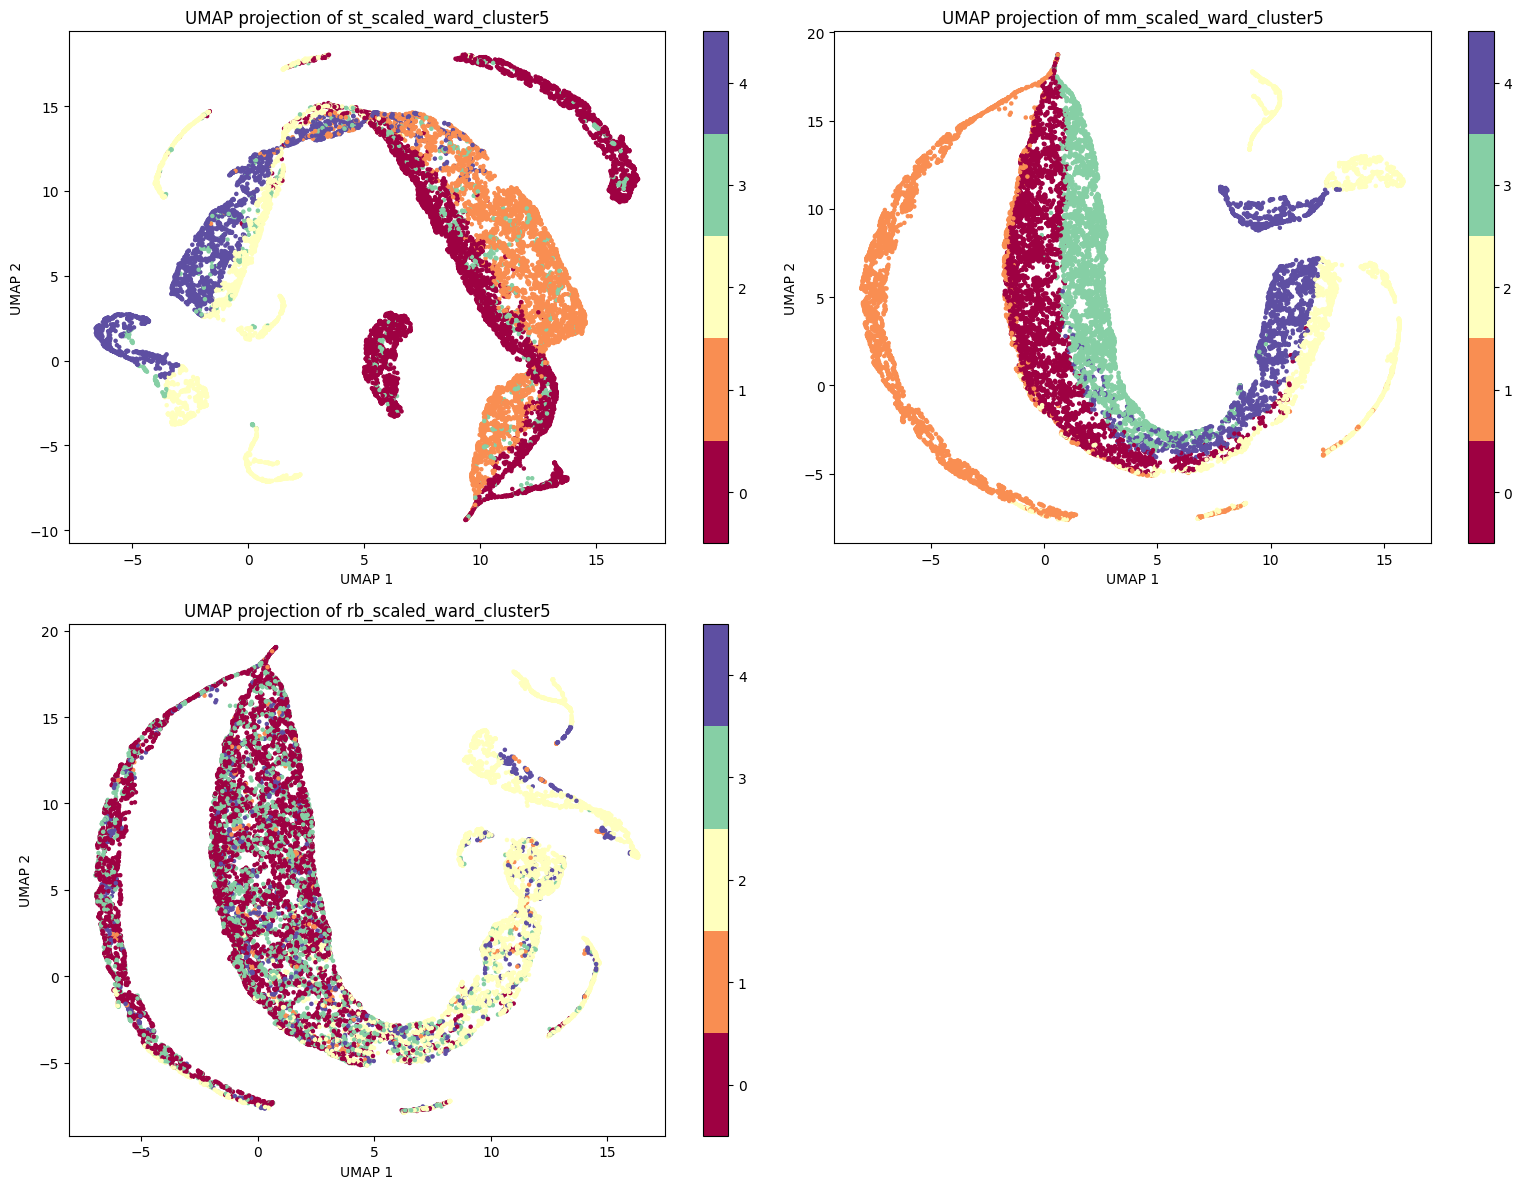

In [34]:
plot_umap_projections(data, cluster_ward)

In [35]:
groupby_mean(data, 'mm_scaled_ward_cluster5')

mm_scaled_ward_cluster5,0,1,2,3,4
Income,34860.919853,2051.989244,15172.287944,76094.183911,67002.741281
Customer Lifetime Value,8161.959801,7598.574218,7840.736167,8064.507936,8175.857125
EnrollmentType,0.048088,0.041570,0.116573,0.038473,0.122871
rejoined_program,0.000229,0.000581,0.034540,0.000000,0.034874
Days_in_prog,1383.703000,1377.166279,460.672202,1407.086855,510.832117
Cancelled_program,0.028853,0.032267,0.323813,0.030603,0.296431
Enrollment_year,2017.690405,2017.704070,2019.448356,2017.618770,2019.417275
Enrollment_month,6.506068,6.508140,6.979077,6.593996,6.880373
TotalFlights,190.009480,191.412384,43.718765,192.817662,51.720316
TotalDistance,384058.243119,383931.531773,81815.925673,391210.624249,96907.339822


### 4.1 Cluster Extraction 1

We will extract **Clusters 1 and 3** as they demonstrate:
- Clear, distinct behavioral patterns
- Minimal overlap with other segments in UMAP space

**Cluster 1 - Description:**
- Profile: Low Income, Low Customer Lifetime Value but has recent flights
- Status: Active but low value
<br><br>

**Cluster 3 - Description:**
- Profile: Highest Income (~76k), highest Total Distance, and highest flights per day.
- Status: Active. These users have high spend across all months and very low Recency (meaning they flew very recently).
- **Overall:** elite loyalists
<br><br>

In [36]:
# Low Income but High Activity -> Value driven by habitual engagement, not income
Elite_High_Value_Loyalists = data[data['mm_scaled_ward_cluster5'] == 3]
#
Low_Value_Active = data[data['mm_scaled_ward_cluster5'] == 1]

### 4.2 Preparation for next extraction

In [37]:
# List of cluster labels to exclude
exclude_clusters = [1,3]

# Filter the original dataset to exclude rows with specified cluster labels
data_filtered1 = data[~data['mm_scaled_ward_cluster5'].isin(exclude_clusters)]

In [38]:
data_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Location__4,Location__5,Location__6,Location__7,st_scaled_km_cluster5,st_scaled_ward_cluster5,mm_scaled_km_cluster5,mm_scaled_ward_cluster5,rb_scaled_km_cluster5,rb_scaled_ward_cluster5
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,0,0,0,0,1,2,4,2,2,2
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,1,0,0,0,1,2,4,2,2,2
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,0,1,0,0,1,2,4,2,2,2
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,0,0,0,0,1,2,4,2,2,2
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,1,0,0,0,1,2,4,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,0.0,0.0,...,1,0,0,0,1,2,4,2,2,2
999996,34148.0,5780.18,0,0,0.0,0,2018,9,0.0,0.0,...,0,0,0,0,1,2,4,2,2,2
999997,34148.0,5780.18,0,0,0.0,0,2020,1,0.0,0.0,...,0,0,0,0,1,2,4,2,2,2


In [39]:
data_filtered1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9844 entries, 100011 to 999999
Data columns (total 69 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Income                          9844 non-null   float64
 1   Customer Lifetime Value         9844 non-null   float64
 2   EnrollmentType                  9844 non-null   int64  
 3   rejoined_program                9844 non-null   int64  
 4   Days_in_prog                    9844 non-null   float64
 5   Cancelled_program               9844 non-null   int64  
 6   Enrollment_year                 9844 non-null   int64  
 7   Enrollment_month                9844 non-null   int64  
 8   TotalFlights                    9844 non-null   float64
 9   TotalDistance                   9844 non-null   float64
 10  TotalPointsAccumulated          9844 non-null   float64
 11  TotalPointsRedeemed             9844 non-null   float64
 12  Flights_per_day                 

In [40]:
data_filtered1 = data_filtered1.loc[:, ~data_filtered1.columns.str.startswith(("st_", "mm_", "rb_"))]

In [42]:
data_filtered1

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Marital_Married,Marital_Single,Location__0,Location__1,Location__2,Location__3,Location__4,Location__5,Location__6,Location__7
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,1,0,0,1,0,0,0,0,0,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,1,0,0,0,0,0,0,1,0,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,1,0,0,0,0,1,0,0,0,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,1,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,0.0,0.0,...,1,0,0,0,0,0,1,0,0,0
999996,34148.0,5780.18,0,0,0.0,0,2018,9,0.0,0.0,...,0,1,0,1,0,0,0,0,0,0
999997,34148.0,5780.18,0,0,0.0,0,2020,1,0.0,0.0,...,1,0,0,0,0,1,0,0,0,0


## <h2 style="color: #333333; background-color: #d6fff4; text-align: center; padding: 6px; font-family: 'Arial';">Filtering: Examination 2</h2>

## Re-Scaling Data

In [ ]:
data_filtered2 = data_filtered1.copy()

In [44]:
value_based_data_2 = data_filtered2[["Customer Lifetime Value", "Income", "Avg_spent_per_flight", "TotalPointsAccumulated", 
                              "TotalPointsRedeemed"]].copy()

In [45]:
value_st_scl_2 = st_scaler.fit_transform(value_based_data_2)
value_rb_scl_2 = rb_scaler.fit_transform(value_based_data_2)

## 1. Standard Scaling

### 1.1 K-Means

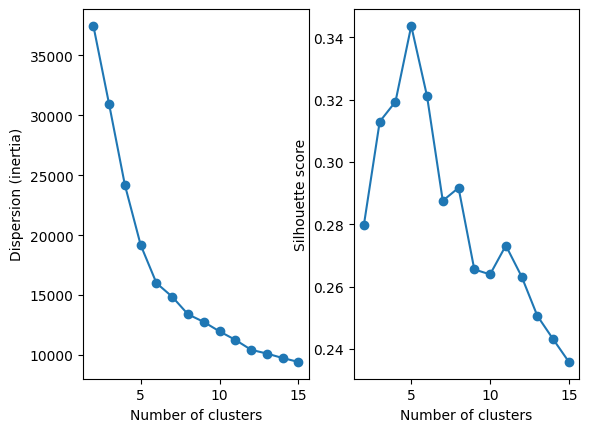

In [46]:
plot_inertia_and_silhouette(value_st_scl_2)

In [47]:
kmeans_st_scl_2 = KMeans(n_clusters=2, random_state=42).fit(value_st_scl_2)
data_filtered2['st_scaled_km2_cluster2'] = kmeans_st_scl_2.predict(value_st_scl_2)

In [48]:
value_st_scl_2['st_scaled_km2_cluster2'] = data_filtered2['st_scaled_km2_cluster2'] 
groupby_mean(value_st_scl_2, 'st_scaled_km2_cluster2', n_features=4)  

st_scaled_km2_cluster2,0,1
Customer Lifetime Value,-0.006834,0.775468
Income,-0.001458,0.165420
Avg_spent_per_flight,-0.078579,8.915983
TotalPointsAccumulated,0.010318,-1.170787
TotalPointsRedeemed,0.006355,-0.721092


### 1.2 Hierarchical - Ward

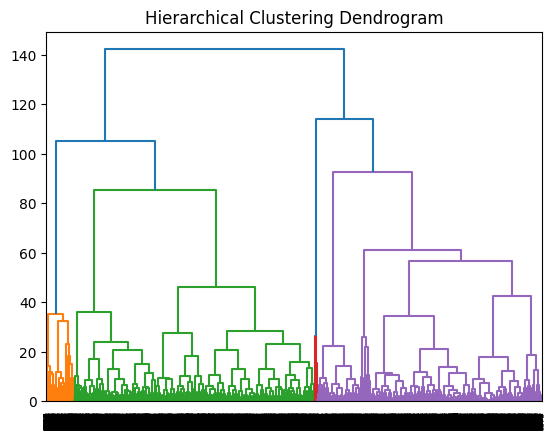

In [49]:
plot_dendrogram(value_st_scl_2, 'ward')

In [50]:
data_filtered2['st_scaled_ward2_cluster2'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 2
    ).fit_predict(value_st_scl_2)

In [51]:
value_st_scl_2['st_scaled_ward2_cluster2'] = data_filtered2['st_scaled_ward2_cluster2']
groupby_mean(value_st_scl_2, 'st_scaled_ward2_cluster2', n_features=4)

st_scaled_ward2_cluster2,0,1
Customer Lifetime Value,-0.136330,0.115128
Income,-0.065030,0.054916
Avg_spent_per_flight,0.186163,-0.157211
TotalPointsAccumulated,-0.885042,0.747402
TotalPointsRedeemed,-0.613255,0.517883


## 2. Robust Scaling

### 2.1 K-Means

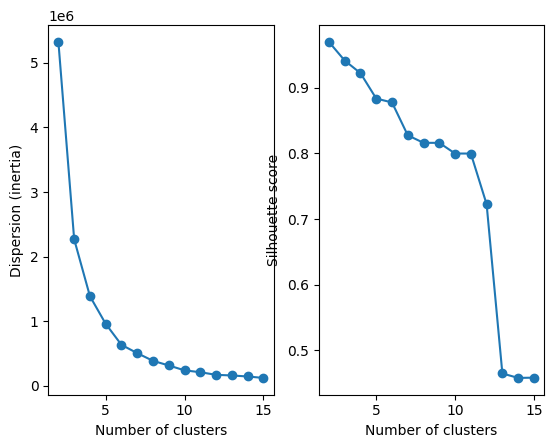

In [52]:
plot_inertia_and_silhouette(value_rb_scl_2)

In [53]:
kmeans_rb_scl_2 = KMeans(n_clusters=2, random_state=42).fit(value_rb_scl_2)
data_filtered2['rb_scaled_km2_cluster2'] = kmeans_rb_scl_2.predict(value_rb_scl_2)

In [54]:
value_rb_scl_2['rb_scaled_km2_cluster2'] = data_filtered2['rb_scaled_km2_cluster2']
groupby_mean(value_rb_scl_2, 'rb_scaled_km2_cluster2', n_features=4)

rb_scaled_km2_cluster2,0,1
Customer Lifetime Value,0.450765,1.523237
Income,0.096712,0.282520
Avg_spent_per_flight,4.530300,424.560088
TotalPointsAccumulated,0.033160,-0.603653
TotalPointsRedeemed,0.268344,-0.320541


### 2.2 Hierarchical - Ward

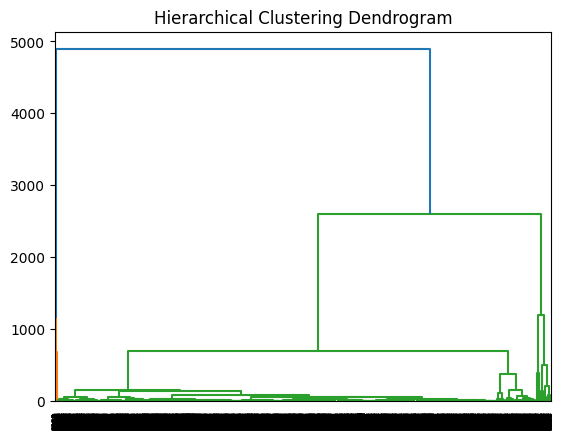

In [55]:
plot_dendrogram(value_rb_scl_2, 'ward')

In [56]:
data_filtered2['rb_scaled_ward2_cluster2'] = AgglomerativeClustering(
    linkage='ward', n_clusters=2
).fit_predict(value_rb_scl_2)

In [57]:
value_rb_scl_2['rb_scaled_ward2_cluster2'] = data_filtered2['rb_scaled_ward2_cluster2']
groupby_mean(value_rb_scl_2, 'rb_scaled_ward2_cluster2', n_features=4)

rb_scaled_ward2_cluster2,0,1
Customer Lifetime Value,0.451554,1.846938
Income,0.096731,0.362123
Avg_spent_per_flight,5.094931,500.276309
TotalPointsAccumulated,0.031738,-0.605310
TotalPointsRedeemed,0.267125,-0.341283


## 3. Cluster Visualization 2

In [58]:
clusters_km2 = ['st_scaled_km2_cluster2', 'rb_scaled_km2_cluster2']

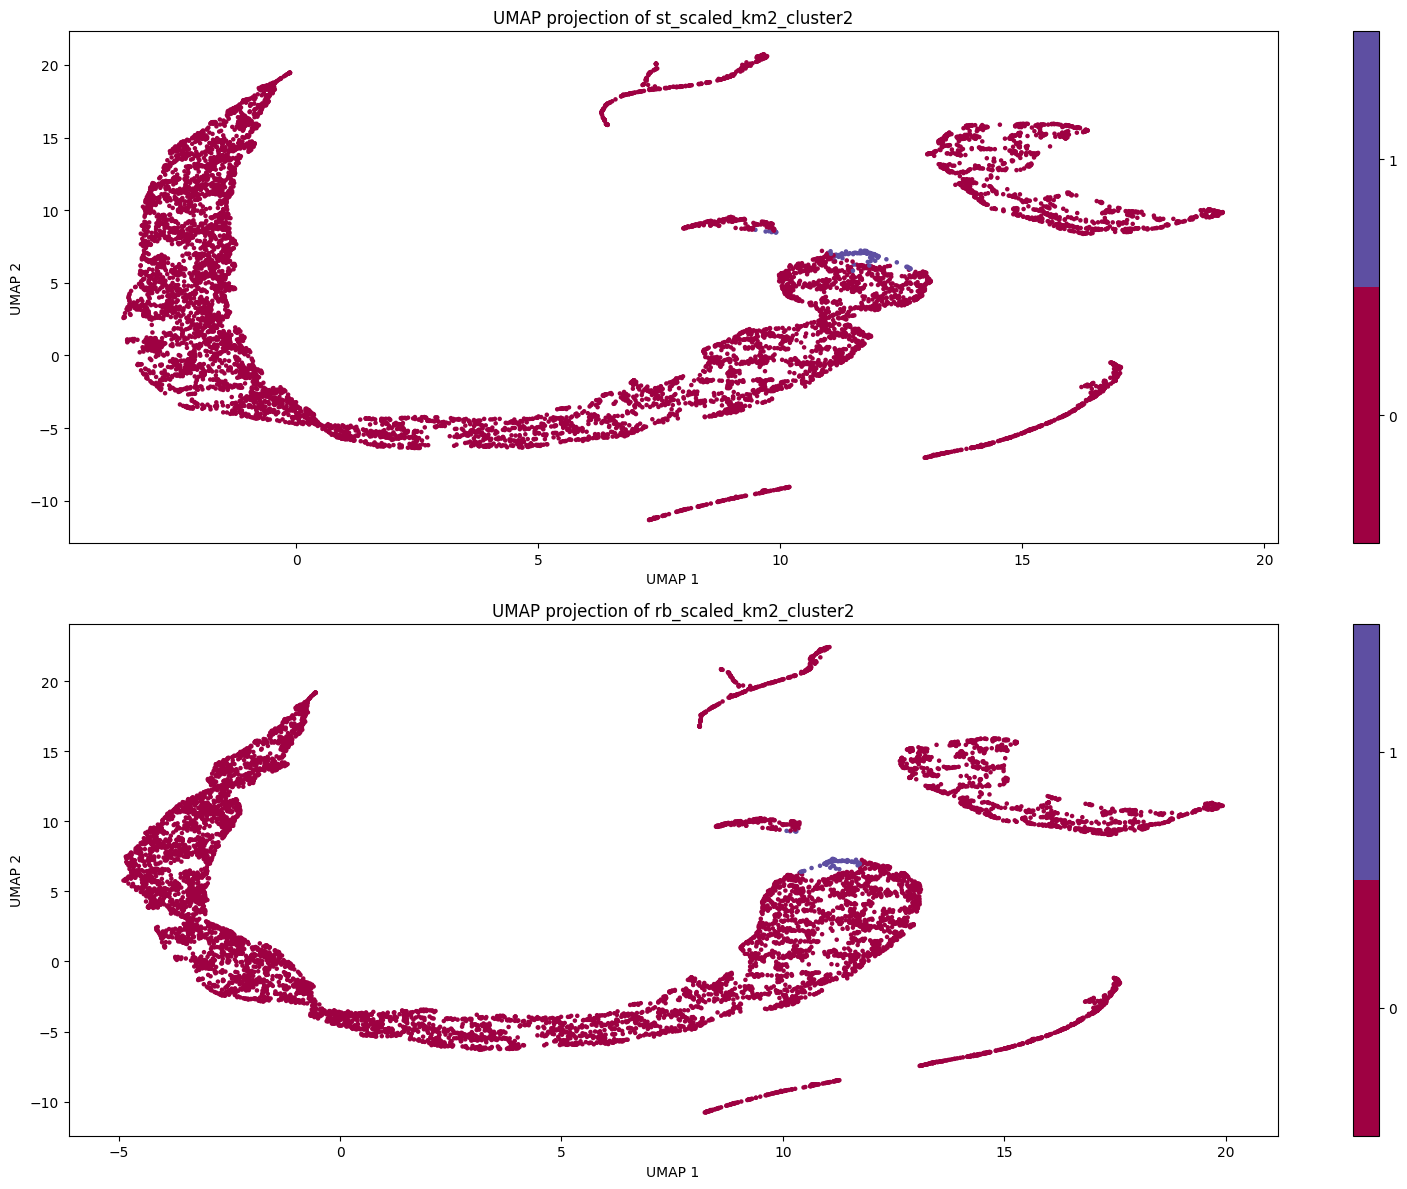

In [59]:
plot_umap_projections(data_filtered2, clusters_km2)

In [60]:
cluster_ward2 = ['st_scaled_ward2_cluster2', 'rb_scaled_ward2_cluster2']

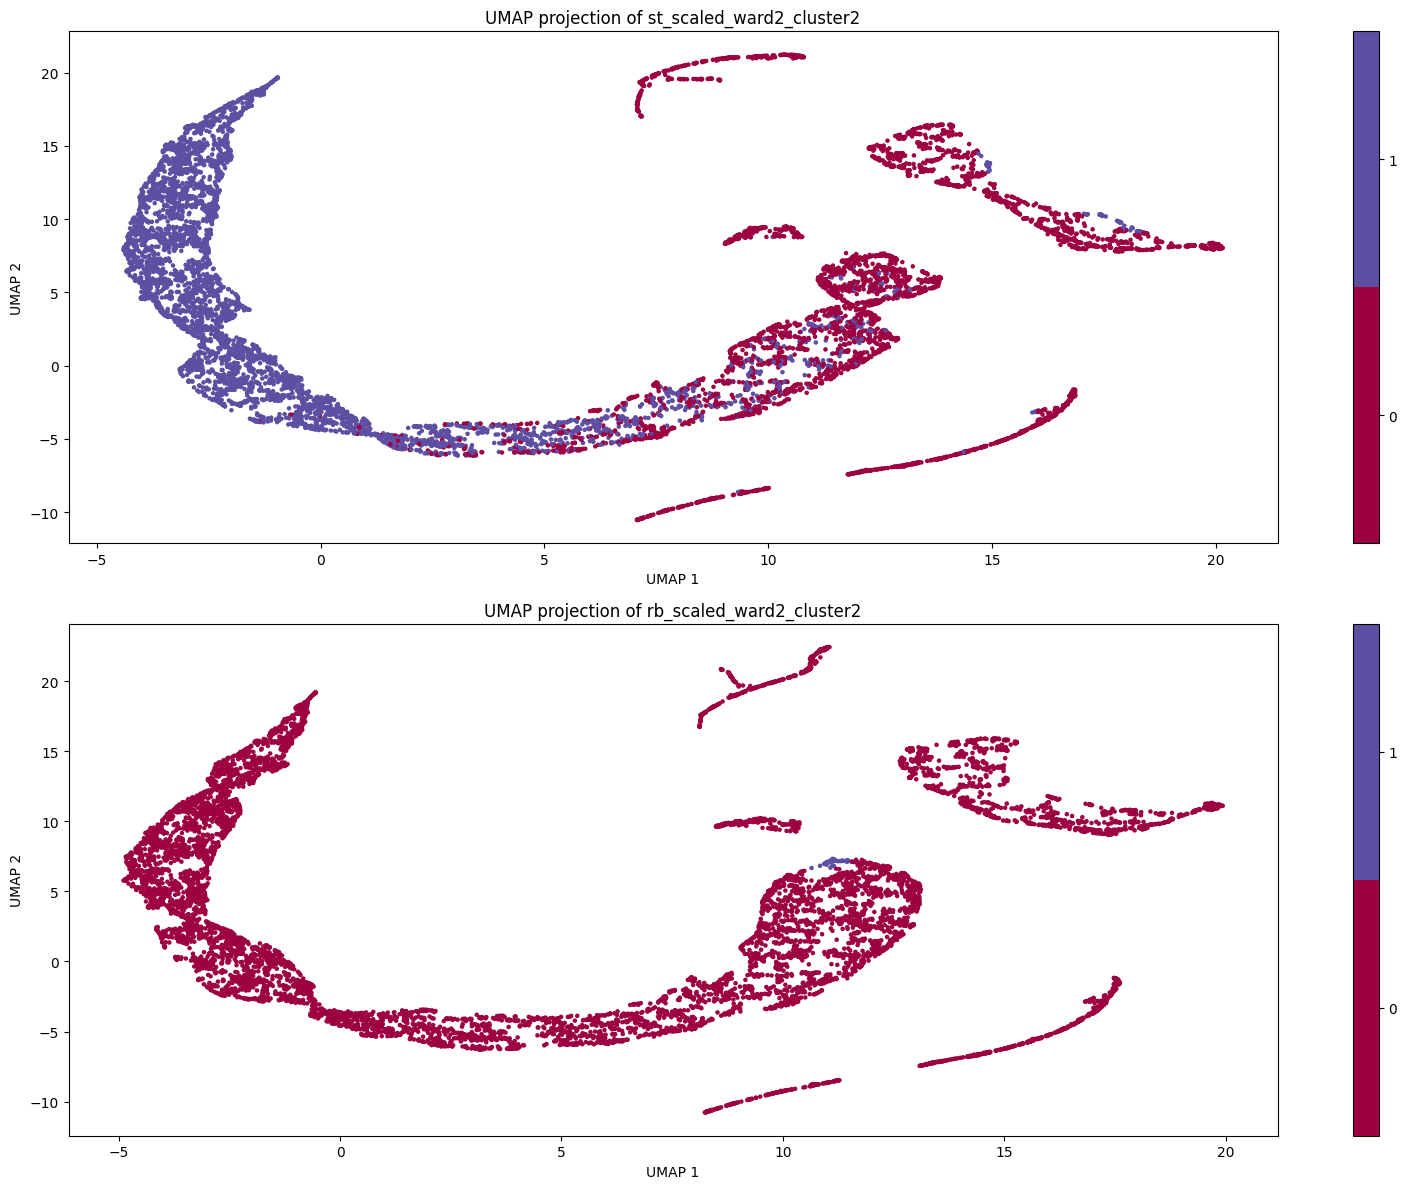

In [61]:
plot_umap_projections(data_filtered2, cluster_ward2)

In [62]:
groupby_mean(data_filtered2, 'st_scaled_ward2_cluster2')

st_scaled_ward2_cluster2,0,1
Income,35377.998447,38167.794079
Customer Lifetime Value,7107.896783,8877.292097
EnrollmentType,0.122032,0.058835
rejoined_program,0.038607,0.003185
Days_in_prog,420.687375,1272.885329
Cancelled_program,0.338584,0.057336
Enrollment_year,2019.508542,2017.944726
Enrollment_month,7.030175,6.503279
TotalFlights,35.997271,173.638973
TotalDistance,67250.857178,348398.723365


### 3.1 Cluster Extraction 2

ADICIONAR DESCRIÇÃO DOS CLUSTERS

In [63]:
# Cluster 0
Inactive = data_filtered2[data_filtered2['st_scaled_ward2_cluster2'] == 0]

# Cluster 1 
Core_Loyalists = data_filtered2[data_filtered2['st_scaled_ward2_cluster2'] == 1]

In [64]:
# List of cluster labels to exclude
exclude_clusters2 = [0, 1]

# Filter the original dataset to exclude rows with specified cluster labels
data_filtered3 = data_filtered2[~data_filtered2['st_scaled_ward2_cluster2'].isin(exclude_clusters2)]

In [65]:
data_filtered3 = data_filtered3.loc[:, ~data_filtered3.columns.str.startswith(("st_", "mm_", "rb_"))]

In [66]:
# To confirm if all the data ios assigned to a cluster
data_filtered3

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Marital_Married,Marital_Single,Location__0,Location__1,Location__2,Location__3,Location__4,Location__5,Location__6,Location__7
Loyalty#,,,,,,,,,,,,,,,,,,,,,


In [67]:
data['segment'] = 'Unassigned'

data.loc[Inactive.index, 'segment'] = 'Inactive'
data.loc[Core_Loyalists.index, 'segment'] = 'Core_Loyalists'
data.loc[Elite_High_Value_Loyalists.index, 'segment'] = 'Elite_High_Value_Loyalists'
data.loc[Low_Value_Active.index, 'segment'] = 'Low_Value_Active'

In [68]:
data['segment'].value_counts()

segment
Core_Loyalists                5337
Inactive                      4507
Low_Value_Active              3440
Elite_High_Value_Loyalists    3431
Name: count, dtype: int64

In [69]:
segment_dummies = pd.get_dummies(
    data['segment'],
    prefix='seg',
    dtype=int
)

In [70]:
data.head()

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Location__5,Location__6,Location__7,st_scaled_km_cluster5,st_scaled_ward_cluster5,mm_scaled_km_cluster5,mm_scaled_ward_cluster5,rb_scaled_km_cluster5,rb_scaled_ward_cluster5,segment
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,0,0,0,1,2,4,2,2,2,Inactive
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,0,0,1,2,4,2,2,2,Inactive
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,1,0,0,1,2,4,2,2,2,Inactive
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,0,0,0,1,2,4,2,2,2,Inactive
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,0,0,0,1,2,4,2,2,2,Inactive


In [71]:
people = pd.concat([data, segment_dummies], axis=1)

In [72]:
people.drop(columns=['segment'], inplace=True)

In [73]:
people = people.loc[:, ~people.columns.str.startswith(("st_", "mm_", "rb_"))]

In [74]:
people.head()

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Location__2,Location__3,Location__4,Location__5,Location__6,Location__7,seg_Core_Loyalists,seg_Elite_High_Value_Loyalists,seg_Inactive,seg_Low_Value_Active
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,0,0,0,0,0,0,0,0,1,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,0,1,0,0,0,0,0,1,0
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,0,0,0,1,0,0,0,0,1,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,0,1,0,0,0,0,0,0,1,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,0,0,1,0,0,0,0,0,1,0


In [75]:
people.to_csv('value_based_perspective_clusters.csv')